In [1]:
from sklearn.cluster import KMeans
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import imageio.v2 as imageio

/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=899
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=450
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=225
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=804
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning

PCA Components and their contributions:

Principal Component 1:
ZCR: 0.252
MFCC_9: -0.252
Chroma_11: -0.248
Chroma_12: -0.234
Chroma_1: -0.220

Principal Component 2:
MFCC_2: 0.295
Spectral_Contrast_2: -0.293
Spectral Bandwidth: -0.259
MFCC_1: 0.235
Spectral_Contrast_5: -0.233

Principal Component 3:
Spectral_Contrast_6: 0.324
MFCC_5: -0.323
Spectral_Contrast_7: 0.317
MFCC_13: -0.278
Spectral_Contrast_4: 0.251


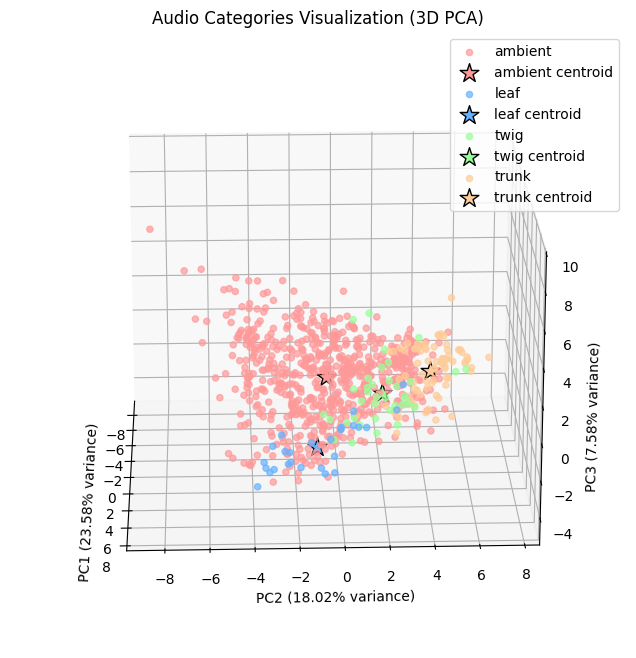


Explained variance ratios:
PC1: 23.58%
PC2: 18.02%
PC3: 7.58%

Mean features by category:

AMBIENT:
RMS: -0.286
ZCR: -0.100
Spectral Centroid: 0.057
Spectral Bandwidth: 0.176
MFCC_1: -0.315
MFCC_2: -0.217
MFCC_3: 0.124
MFCC_4: 0.167
MFCC_5: 0.126
MFCC_6: 0.223
MFCC_7: 0.125
MFCC_8: 0.002
MFCC_9: 0.119
MFCC_10: 0.071
MFCC_11: 0.068
MFCC_12: 0.108
MFCC_13: 0.083
Chroma_1: -0.001
Chroma_2: 0.004
Chroma_3: 0.054
Chroma_4: 0.035
Chroma_5: -0.013
Chroma_6: 0.074
Chroma_7: 0.104
Chroma_8: 0.005
Chroma_9: 0.016
Chroma_10: -0.008
Chroma_11: 0.051
Chroma_12: 0.071
Tonnetz_1: 0.126
Tonnetz_2: 0.073
Tonnetz_3: 0.161
Tonnetz_4: 0.120
Tonnetz_5: 0.132
Tonnetz_6: 0.146

LEAF:
RMS: 0.143
ZCR: 0.976
Spectral Centroid: 1.026
Spectral Bandwidth: 0.661
MFCC_1: 0.627
MFCC_2: -0.516
MFCC_3: -0.297
MFCC_4: 0.008
MFCC_5: 0.583
MFCC_6: -0.493
MFCC_7: -0.550
MFCC_8: 0.182
MFCC_9: -0.669
MFCC_10: -0.965
MFCC_11: -0.313
MFCC_12: 0.004
MFCC_13: -0.035
Chroma_1: -1.003
Chroma_2: -0.915
Chroma_3: -0.794
Chroma_4: -

In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import imageio.v2 as imageio

# Function to extract features from audio file
def extract_features(audio_path):
    y, sr = librosa.load(audio_path)
    
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).mean(axis=1)
    rms = librosa.feature.rms(y=y)[0].mean()
    zcr = librosa.feature.zero_crossing_rate(y=y)[0].mean()
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0].mean()
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0].mean()
    chroma = librosa.feature.chroma_stft(y=y, sr=sr).mean(axis=1)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr).mean(axis=1)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0].mean()
    tonnetz = librosa.feature.tonnetz(y=y, sr=sr).mean(axis=1)
    
    # Combine features into a single flat array
    features = np.concatenate([[rms, zcr, spec_cent, spec_bw], mfccs, chroma, spectral_contrast, tonnetz])
    return features

categories = ['ambient', 'leaf', 'twig', 'trunk']
X = []
y = []
filenames = []

for category in categories:
    category_path = os.path.join('./output', category)
    for file in os.listdir(category_path):
        if file.endswith('.wav'):
            file_path = os.path.join(category_path, file)
            features = extract_features(file_path)
            X.append(features)
            y.append(category)
            filenames.append(file)

X = np.array(X)
y = np.array(y)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create feature names list
feature_names = ['RMS', 'ZCR', 'Spectral Centroid', 'Spectral Bandwidth'] + \
                [f'MFCC_{i+1}' for i in range(13)] + \
                [f'Chroma_{i+1}' for i in range(12)] + \
                [f'Spectral_Contrast_{i+1}' for i in range(7)] + \
                [f'Tonnetz_{i+1}' for i in range(6)]

# Get PCA components and their contributions
print("PCA Components and their contributions:")
for i, component in enumerate(pca.components_):
    print(f"\nPrincipal Component {i+1}:")
    # Get the feature indices sorted by absolute weight
    sorted_idx = np.argsort(np.abs(component))[::-1]
    for idx in sorted_idx[:5]:  # Show top 5 contributing features
        print(f"{feature_names[idx]}: {component[idx]:.3f}")

# Create 3D plot with animation
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each category with different colors and calculate centroids
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
for category, color in zip(categories, colors):
    mask = y == category
    category_points = X_pca[mask]
    
    # Plot points
    ax.scatter(category_points[:, 0], category_points[:, 1], category_points[:, 2], 
              label=category, alpha=0.7, c=color)
    
    # Calculate and plot centroid
    centroid = np.mean(category_points, axis=0)
    ax.scatter(centroid[0], centroid[1], centroid[2], 
              c=color, marker='*', s=200, edgecolor='black', linewidth=1,
              label=f'{category} centroid')

# Add labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)')
ax.set_title('Audio Categories Visualization (3D PCA)')
plt.legend()

# Animation function
def rotate(frame):
    ax.view_init(elev=20., azim=frame)
    return fig,

# Create animation
anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), 
                    interval=50, blit=True)

# Save as GIF
anim.save('3d_plot_rotation.gif', writer='pillow')

plt.show()

# Print explained variance ratios
print("\nExplained variance ratios:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.2%}")

# Feature analysis
feature_names = ['RMS', 'ZCR', 'Spectral Centroid', 'Spectral Bandwidth'] + \
                [f'MFCC_{i+1}' for i in range(13)] + \
                [f'Chroma_{i+1}' for i in range(12)] + \
                [f'Tonnetz_{i+1}' for i in range(6)]

# Calculate mean features for each category
print("\nMean features by category:")
for category in categories:
    mask = y == category
    category_features = X_scaled[mask]
    mean_features = category_features.mean(axis=0)
    print(f"\n{category.upper()}:")
    for name, value in zip(feature_names, mean_features):
        print(f"{name}: {value:.3f}")

# After PCA fitting
print("Feature contributions to each principal component:")
for i, component in enumerate(pca.components_):
    print(f"\nPC{i+1} composition:")
    # Get feature contributions sorted by absolute magnitude
    feature_importance = list(zip(feature_names, component))
    feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)
    # Print top 5 contributing features
    for feat, weight in feature_importance[:5]:
        print(f"{feat}: {weight:.3f}")

/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=632
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=316
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=799
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=625
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=313
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning

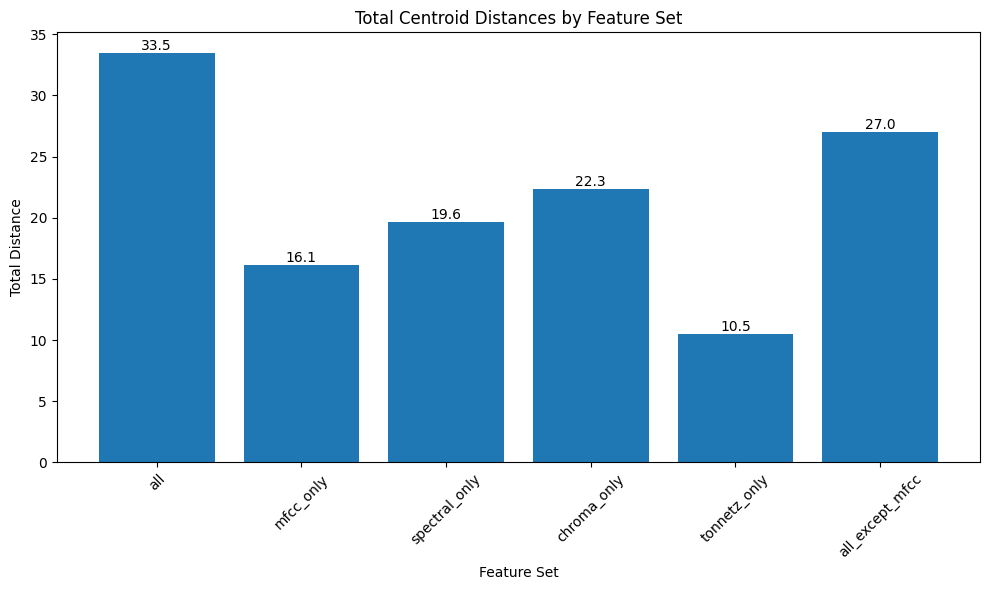


Best feature set: all
Total centroid distance: 33.486

Pairwise distances:
ambient - leaf: 5.942
ambient - twig: 6.694
ambient - trunk: 8.321
leaf - twig: 3.794
leaf - trunk: 6.256
twig - trunk: 2.478

Explained variance ratios: [0.1891169  0.14734823 0.09947315]


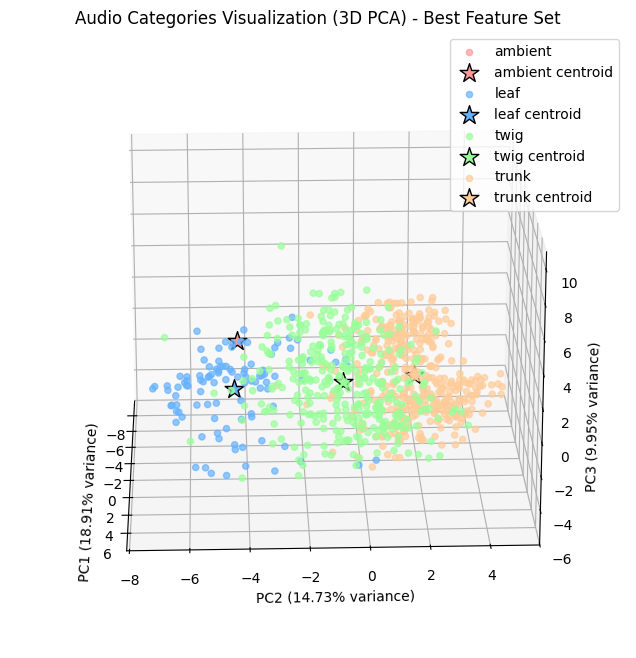

In [20]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import imageio.v2 as imageio
from itertools import combinations
from scipy.spatial.distance import euclidean

# Function to extract features from audio file
def extract_features(audio_path):
    y, sr = librosa.load(audio_path)
    
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).mean(axis=1)
    rms = librosa.feature.rms(y=y)[0].mean()
    zcr = librosa.feature.zero_crossing_rate(y=y)[0].mean()
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0].mean()
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0].mean()
    chroma = librosa.feature.chroma_stft(y=y, sr=sr).mean(axis=1)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr).mean(axis=1)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0].mean()
    tonnetz = librosa.feature.tonnetz(y=y, sr=sr).mean(axis=1)
    
    # Combine features into a single flat array
    features = np.concatenate([[rms, zcr, spec_cent, spec_bw], mfccs, chroma, spectral_contrast, tonnetz])
    return features

def calculate_centroid_distances(X_transformed, y, categories):
    # Calculate centroids for each category
    centroids = {}
    for category in categories:
        mask = y == category
        category_points = X_transformed[mask]
        centroids[category] = np.mean(category_points, axis=0)
    
    # Calculate pairwise distances between centroids
    distances = []
    total_distance = 0
    for cat1, cat2 in combinations(categories, 2):
        dist = euclidean(centroids[cat1], centroids[cat2])
        distances.append((cat1, cat2, dist))
        total_distance += dist
    
    return distances, total_distance

# Test different feature combinations
feature_sets = {
    'all': slice(None),
    'mfcc_only': slice(4, 17),
    'spectral_only': slice(0, 4),
    'chroma_only': slice(17, 29),
    'tonnetz_only': slice(-6, None),
    'all_except_mfcc': np.r_[0:4, 17:29, -6:None]
}

categories = ['ambient', 'leaf', 'twig', 'trunk']
X = []
y = []

for category in categories:
    category_path = os.path.join('./output', category)
    for file in os.listdir(category_path):
        if file.endswith('.wav'):
            file_path = os.path.join(category_path, file)
            features = extract_features(file_path)
            X.append(features)
            y.append(category)

X = np.array(X)
y = np.array(y)

# Test each feature set and store results
results = {}
total_distances = []
feature_names = []

for name, feature_slice in feature_sets.items():
    # Select features
    X_subset = X[:, feature_slice]
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_subset)
    
    # Apply PCA
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_scaled)
    
    # Calculate centroid distances
    distances, total_distance = calculate_centroid_distances(X_pca, y, categories)
    results[name] = {
        'total_distance': total_distance,
        'distances': distances,
        'explained_variance': pca.explained_variance_ratio_
    }
    total_distances.append(total_distance)
    feature_names.append(name)

# Plot total distances for each feature set
plt.figure(figsize=(10, 6))
bars = plt.bar(feature_names, total_distances)
plt.title('Total Centroid Distances by Feature Set')
plt.xlabel('Feature Set')
plt.ylabel('Total Distance')
plt.xticks(rotation=45)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Find best feature set
best_set = max(results.items(), key=lambda x: x[1]['total_distance'])
print(f"\nBest feature set: {best_set[0]}")
print(f"Total centroid distance: {best_set[1]['total_distance']:.3f}")
print("\nPairwise distances:")
for cat1, cat2, dist in best_set[1]['distances']:
    print(f"{cat1} - {cat2}: {dist:.3f}")
print("\nExplained variance ratios:", best_set[1]['explained_variance'])

# Use best feature set for visualization
best_features = X[:, feature_sets[best_set[0]]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(best_features)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create 3D plot with animation
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each category with different colors and calculate centroids
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
for category, color in zip(categories, colors):
    mask = y == category
    category_points = X_pca[mask]
    
    # Plot points
    ax.scatter(category_points[:, 0], category_points[:, 1], category_points[:, 2], 
              label=category, alpha=0.7, c=color)
    
    # Calculate and plot centroid
    centroid = np.mean(category_points, axis=0)
    ax.scatter(centroid[0], centroid[1], centroid[2], 
              c=color, marker='*', s=200, edgecolor='black', linewidth=1,
              label=f'{category} centroid')

# Add labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)')
ax.set_title('Audio Categories Visualization (3D PCA) - Best Feature Set')
plt.legend()

# Animation function
def rotate(frame):
    ax.view_init(elev=20., azim=frame)
    return fig,

# Create animation
anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), 
                    interval=50, blit=True)

# Save as GIF
anim.save('3d_plot_rotation.gif', writer='pillow')

plt.show()

/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=632
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=316
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=799
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=625
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=313
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning

Mean features by category:

AMBIENT:
RMS: -1.045
ZCR: -1.246
Spectral Centroid: 2.701
Spectral Bandwidth: 3.805
MFCC_1: -3.561
MFCC_2: -2.681
MFCC_3: 1.394
MFCC_4: 0.259
MFCC_5: 1.753
MFCC_6: -0.560
MFCC_7: -0.899
MFCC_8: 0.451
MFCC_9: 0.826
MFCC_10: 0.788
MFCC_11: 1.338
MFCC_12: 1.382
MFCC_13: -0.100
Chroma_1: 1.521
Chroma_2: 1.666
Chroma_3: 1.422
Chroma_4: 0.822
Chroma_5: 0.686
Chroma_6: 1.068
Chroma_7: 1.734
Chroma_8: 1.733
Chroma_9: 2.481
Chroma_10: 1.548
Chroma_11: 1.460
Chroma_12: 1.348
Spectral_Contrast_1: 2.044
Spectral_Contrast_2: 2.289
Spectral_Contrast_3: 1.782
Spectral_Contrast_4: 2.154
Spectral_Contrast_5: 1.793
Spectral_Contrast_6: 0.851
Spectral_Contrast_7: -0.016
Tonnetz_1: -0.552
Tonnetz_2: -0.657
Tonnetz_3: 0.742
Tonnetz_4: -0.856
Tonnetz_5: -1.597
Tonnetz_6: 0.916

LEAF:
RMS: -0.705
ZCR: 0.450
Spectral Centroid: 1.628
Spectral Bandwidth: 1.635
MFCC_1: -1.341
MFCC_2: -1.267
MFCC_3: -0.245
MFCC_4: -0.089
MFCC_5: 0.239
MFCC_6: 0.083
MFCC_7: 0.836
MFCC_8: 0.802
MFCC_9: 0

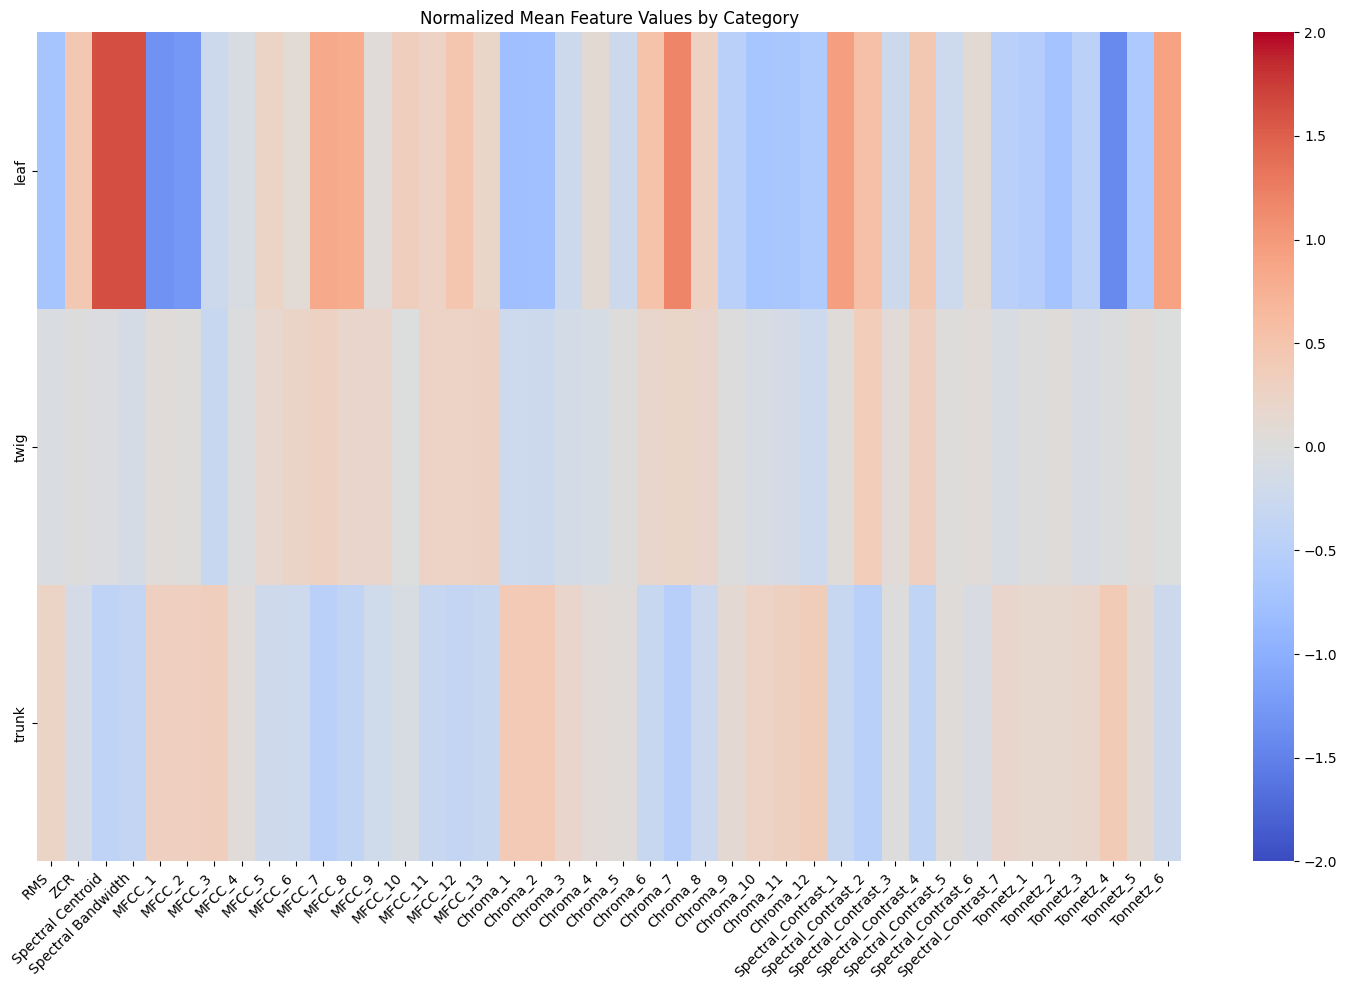


Feature importance based on PCA:

Principal Component 1 (Explains 18.91% of variance):
ZCR: 0.264
Chroma_11: -0.234
Chroma_10: -0.233
Chroma_12: -0.232
MFCC_2: 0.225

Principal Component 2 (Explains 14.73% of variance):
Tonnetz_4: 0.280
Spectral Bandwidth: -0.264
Chroma_7: -0.258
Spectral Centroid: -0.250
MFCC_2: 0.242

Principal Component 3 (Explains 9.95% of variance):
Spectral_Contrast_3: 0.276
MFCC_10: -0.256
MFCC_12: 0.251
MFCC_8: -0.250
Chroma_7: -0.250


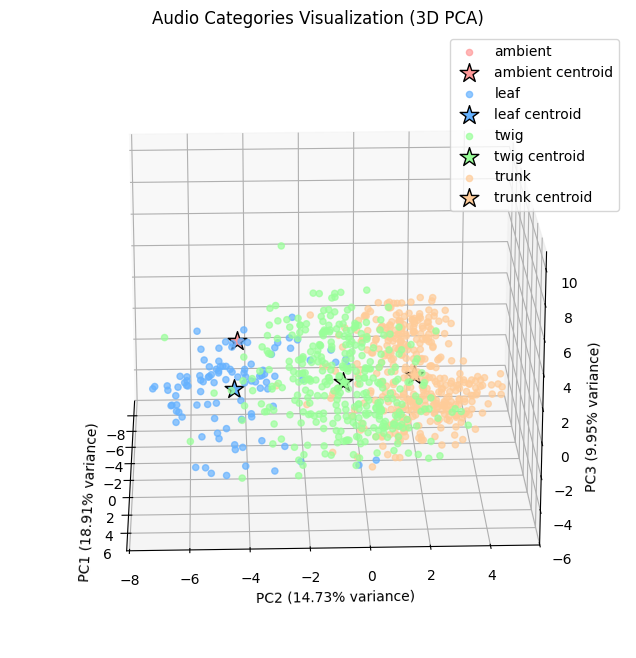

In [25]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import imageio.v2 as imageio

# Function to extract features from audio file
def extract_features(audio_path):
    y, sr = librosa.load(audio_path)
    
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).mean(axis=1)
    rms = librosa.feature.rms(y=y)[0].mean()
    zcr = librosa.feature.zero_crossing_rate(y=y)[0].mean()
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0].mean()
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0].mean()
    chroma = librosa.feature.chroma_stft(y=y, sr=sr).mean(axis=1)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr).mean(axis=1)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0].mean()
    tonnetz = librosa.feature.tonnetz(y=y, sr=sr).mean(axis=1)
    
    # Combine features into a single flat array
    features = np.concatenate([[rms, zcr, spec_cent, spec_bw], mfccs, chroma, spectral_contrast, tonnetz])
    return features

categories = ['ambient', 'leaf', 'twig', 'trunk']
X = []
y = []
filenames = []

for category in categories:
    category_path = os.path.join('./output', category)
    for file in os.listdir(category_path):
        if file.endswith('.wav'):
            file_path = os.path.join(category_path, file)
            features = extract_features(file_path)
            X.append(features)
            y.append(category)
            filenames.append(file)

X = np.array(X)
y = np.array(y)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create feature names list
feature_names = ['RMS', 'ZCR', 'Spectral Centroid', 'Spectral Bandwidth'] + \
                [f'MFCC_{i+1}' for i in range(13)] + \
                [f'Chroma_{i+1}' for i in range(12)] + \
                [f'Spectral_Contrast_{i+1}' for i in range(7)] + \
                [f'Tonnetz_{i+1}' for i in range(6)]

# Calculate and display mean features for each category using scaled features
print("Mean features by category:")
mean_features_by_category = {}
for category in categories:
    mask = y == category
    category_features = X_scaled[mask]  # Using scaled features for better visualization
    mean_features = category_features.mean(axis=0)
    mean_features_by_category[category] = mean_features
    
    print(f"\n{category.upper()}:")
    for name, value in zip(feature_names, mean_features):
        print(f"{name}: {value:.3f}")

# Create a heatmap of mean features using scaled values, excluding ambient
plt.figure(figsize=(15, 10))
categories_no_ambient = [cat for cat in categories if cat != 'ambient']
mean_features_matrix = np.array([mean_features_by_category[cat] for cat in categories_no_ambient])
sns.heatmap(mean_features_matrix, 
            xticklabels=feature_names, 
            yticklabels=categories_no_ambient,
            cmap='coolwarm',
            center=0,
            vmin=-2, vmax=2)  # Setting limits for better color contrast
plt.xticks(rotation=45, ha='right')
plt.title('Normalized Mean Feature Values by Category')
plt.tight_layout()
plt.show()

# Calculate feature importance using PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("\nFeature importance based on PCA:")
for i, component in enumerate(pca.components_):
    print(f"\nPrincipal Component {i+1} (Explains {pca.explained_variance_ratio_[i]:.2%} of variance):")
    feature_importance = list(zip(feature_names, component))
    feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)
    for feat, weight in feature_importance[:5]:
        print(f"{feat}: {weight:.3f}")

# 3D visualization
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
for category, color in zip(categories, colors):
    mask = y == category
    category_points = X_pca[mask]
    
    ax.scatter(category_points[:, 0], category_points[:, 1], category_points[:, 2], 
              label=category, alpha=0.7, c=color)
    
    centroid = np.mean(category_points, axis=0)
    ax.scatter(centroid[0], centroid[1], centroid[2], 
              c=color, marker='*', s=200, edgecolor='black', linewidth=1,
              label=f'{category} centroid')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)')
ax.set_title('Audio Categories Visualization (3D PCA)')
plt.legend()

def rotate(frame):
    ax.view_init(elev=20., azim=frame)
    return fig,

anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), 
                    interval=50, blit=True)
anim.save('3d_plot_rotation.gif', writer='pillow')
plt.show()

/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=632
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=316
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=799
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=625
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=313
  warnings.warn(
/Users/dorry/.pyenv/versions/3.9.21/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning

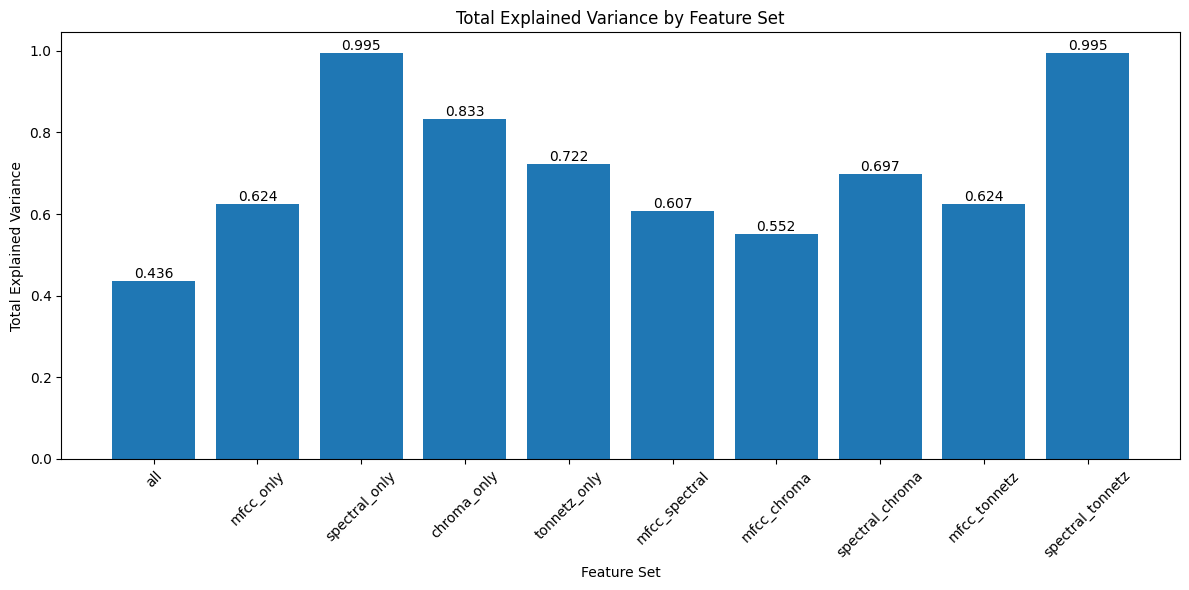


Best feature set: spectral_only
Total explained variance: 0.995

Explained variance ratios: [0.60465107 0.23182785 0.15897415]


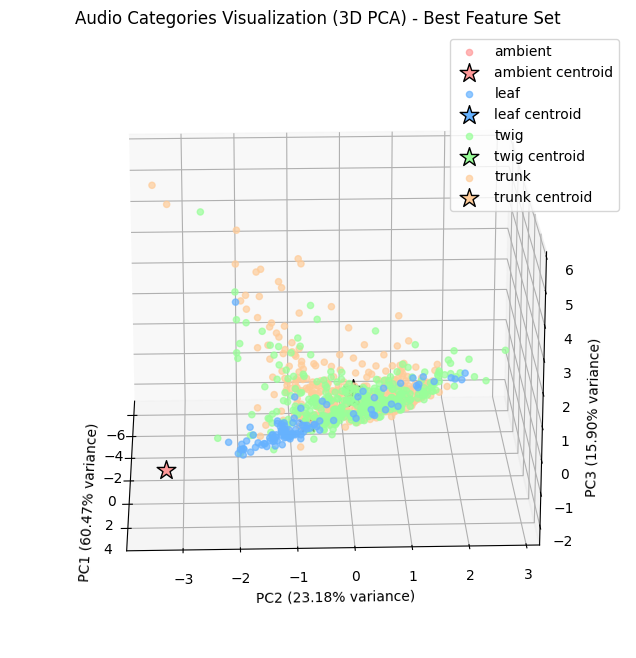

In [22]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import imageio.v2 as imageio
from itertools import combinations
from scipy.spatial.distance import euclidean

# Function to extract features from audio file
def extract_features(audio_path):
    y, sr = librosa.load(audio_path)
    
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).mean(axis=1)
    rms = librosa.feature.rms(y=y)[0].mean()
    zcr = librosa.feature.zero_crossing_rate(y=y)[0].mean()
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0].mean()
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0].mean()
    chroma = librosa.feature.chroma_stft(y=y, sr=sr).mean(axis=1)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr).mean(axis=1)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0].mean()
    tonnetz = librosa.feature.tonnetz(y=y, sr=sr).mean(axis=1)
    
    # Combine features into a single flat array
    features = np.concatenate([[rms, zcr, spec_cent, spec_bw], mfccs, chroma, spectral_contrast, tonnetz])
    return features

# Test different feature combinations
feature_sets = {
    'all': slice(None),
    'mfcc_only': slice(4, 17),
    'spectral_only': slice(0, 4),
    'chroma_only': slice(17, 29),
    'tonnetz_only': slice(-6, None),
    'mfcc_spectral': np.r_[0:17],  # Combining MFCC and spectral
    'mfcc_chroma': np.r_[4:29],    # Combining MFCC and chroma
    'spectral_chroma': np.r_[0:4, 17:29],  # Combining spectral and chroma
    'mfcc_tonnetz': np.r_[4:17, -6:None],  # Combining MFCC and tonnetz
    'spectral_tonnetz': np.r_[0:4, -6:None]  # Combining spectral and tonnetz
}

categories = ['ambient', 'leaf', 'twig', 'trunk']
X = []
y = []

for category in categories:
    category_path = os.path.join('./output', category)
    for file in os.listdir(category_path):
        if file.endswith('.wav'):
            file_path = os.path.join(category_path, file)
            features = extract_features(file_path)
            X.append(features)
            y.append(category)

X = np.array(X)
y = np.array(y)

# Test each feature set and store results
results = {}
explained_variances = []
feature_names = []

for name, feature_slice in feature_sets.items():
    # Select features
    X_subset = X[:, feature_slice]
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_subset)
    
    # Apply PCA
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_scaled)
    
    # Store total explained variance
    total_variance = sum(pca.explained_variance_ratio_)
    results[name] = {
        'explained_variance': pca.explained_variance_ratio_,
        'total_variance': total_variance
    }
    explained_variances.append(total_variance)
    feature_names.append(name)

# Plot explained variances for each feature set
plt.figure(figsize=(12, 6))
bars = plt.bar(feature_names, explained_variances)
plt.title('Total Explained Variance by Feature Set')
plt.xlabel('Feature Set')
plt.ylabel('Total Explained Variance')
plt.xticks(rotation=45)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Find best feature set based on explained variance
best_set = max(results.items(), key=lambda x: x[1]['total_variance'])
print(f"\nBest feature set: {best_set[0]}")
print(f"Total explained variance: {best_set[1]['total_variance']:.3f}")
print("\nExplained variance ratios:", best_set[1]['explained_variance'])

# Use best feature set for visualization
best_features = X[:, feature_sets[best_set[0]]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(best_features)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create 3D plot with animation
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each category with different colors and calculate centroids
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
for category, color in zip(categories, colors):
    mask = y == category
    category_points = X_pca[mask]
    
    # Plot points
    ax.scatter(category_points[:, 0], category_points[:, 1], category_points[:, 2], 
              label=category, alpha=0.7, c=color)
    
    # Calculate and plot centroid
    centroid = np.mean(category_points, axis=0)
    ax.scatter(centroid[0], centroid[1], centroid[2], 
              c=color, marker='*', s=200, edgecolor='black', linewidth=1,
              label=f'{category} centroid')

# Add labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)')
ax.set_title('Audio Categories Visualization (3D PCA) - Best Feature Set')
plt.legend()

# Animation function
def rotate(frame):
    ax.view_init(elev=20., azim=frame)
    return fig,

# Create animation
anim = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), 
                    interval=50, blit=True)

# Save as GIF
anim.save('3d_plot_rotation.gif', writer='pillow')

plt.show()